In [1]:
# ============================================
# 0.1 Parameter definieren
# ============================================

#import random

#N = 1500  # Gesamtzahl der Wohnungen

# Verteilung auf Gemeinden
#gemeenten = {
#    "Groningen": 0.55,
#    "Assen": 0.25,
#    "Leeuwarden": 0.20
#}

# Typische Straßennamen
#straten = [
#    "Lindelaan", "Kerkstraat", "Dorpsweg", "Beukenhof", "Eikenlaan", "Stationsstraat",
#    "Schoolstraat", "Molenweg", "Vijverlaan", "Bergstraat", "Hoofdweg", "Kanaalstraat",
#    "Parklaan", "Wilgenpad", "Achterweg", "Meidoornstraat", "Zonnelaan", "Havenstraat",
#    "Watermolenweg", "Bremstraat", "Esdoornlaan", "Kastanjelaan", "Noorderweg",
#    "Zuiderstraat", "Buitenhof"
#]

# Postcodes + Provinzen
#postcode_ranges = {
#    "Leeuwarden": ("Friesland", range(8901, 8941)),
#    "Assen": ("Drenthe", range(9401, 9409)),
#    "Groningen": ("Groningen", range(9701, 9747))
#}

# Postcode-Buchstaben
#postcode_letters = ["AB", "CD", "EF", "GH", "JK", "LM", "NP", "RS", "TV"]

# ============================================
# 0.2 DataFrame erzeugen
# ============================================

#rows = []

#for gemeente, share in gemeenten.items():
#    n_units = int(N * share)
#    provincie, pc_range = postcode_ranges[gemeente]

#    for _ in range(n_units):
#        straat = random.choice(straten)
#        huisnummer = random.randint(1, 200)
#        postcode = f"{random.choice(pc_range)} {random.choice(postcode_letters)}"

#        rows.append({
#            "Gemeente": gemeente,
#            "Provincie": provincie,
#            "Straat": straat,
#            "Huisnummer": huisnummer,
#            "Postcode": postcode
#        })

# DataFrame erstellen
#df_portfolio = pd.DataFrame(rows)

# Falls durch Rundung nicht exakt 1500 erreicht wurden → auffüllen
#if len(df_portfolio) < N:
#    diff = N - len(df_portfolio)
#    df_portfolio = pd.concat([df_portfolio, df_portfolio.sample(diff, replace=True)], ignore_index=True)

#print("Portfolio mit 1.500 Objekten erfolgreich erzeugt.")
#df_portfolio.head()

In [2]:
#=============================================
# 1. Import Module
#=============================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random

sns.set(style="whitegrid")


In [3]:
# ============================================
# 2. WWS 2022 – Meergezinswoningen
# ============================================

def punten_vertrekken(m2_vertrekken):
    return 1.0 * m2_vertrekken

def punten_overig(m2_overig):
    return 0.75 * m2_overig

def punten_buitenruimte_2022(m2):
    if m2 <= 25:
        return 2
    elif m2 <= 50:
        return 4
    elif m2 <= 75:
        return 6
    elif m2 <= 100:
        return 4
    else:
        return 10

ENERGIE_2022_MEERGEZINS = {
    "A++++": 48,
    "A+++": 44,
    "A++": 40,
    "A+": 36,
    "A": 32,
    "B": 28,
    "C": 15,
    "D": 11,
    "E": 5,
    "F": 1,
    "G": 0
}

def energiepunten_2022(label):
    return ENERGIE_2022_MEERGEZINS.get(label, 0)

def woz_punten_2022(woz, subtotal_ohne_woz):
    woz_raw = woz / 8000
    if subtotal_ohne_woz >= 142:
        cap = subtotal_ohne_woz * 0.33
        return min(woz_raw, cap)
    return woz_raw

KEUKEN_2022 = {
    "Eenvoudig": 0,
    "Standaard": 4,
    "Modern": 10
}

def keuken_punten_2022(keuken_type):
    return KEUKEN_2022.get(keuken_type, 0)

BADKAMER_2022 = {
    "Eenvoudig": 8,
    "Standaard": 11,
    "Modern": 16
}

def badkamer_punten_2022(badkamer_type):
    return BADKAMER_2022.get(badkamer_type, 0)

def lift_punten_2022(verdieping, heeft_lift):
    if heeft_lift:
        return 0
    if verdieping <= 2:
        return 0
    elif verdieping == 3:
        return -2
    elif verdieping == 4:
        return -3
    return -4

def berechne_wws_2022_meergezins(df):
    df = df.copy()

    df["WWS2022_oppervlakte"] = (
        df["m2_vertrekken"] * 1.0 +
        df["m2_overig"] * 0.75
    )

    df["WWS2022_energie"] = df["Energielabel"].apply(energiepunten_2022)

    df["WWS2022_buiten"] = df["Buitenruimte_m2"].apply(punten_buitenruimte_2022)

    df["WWS2022_keuken"] = df["Keuken"].apply(keuken_punten_2022)
    df["WWS2022_badkamer"] = df["Badkamer"].apply(badkamer_punten_2022)
    df["WWS2022_lift"] = df.apply(
        lambda row: lift_punten_2022(row["Verdieping"], row["Lift"]),
        axis=1
    )

    df["WWS2022_subtotal_ohne_WOZ"] = (
        df["WWS2022_oppervlakte"]
        + df["WWS2022_energie"]
        + df["WWS2022_buiten"]
        + df["WWS2022_keuken"]
        + df["WWS2022_badkamer"]
        + df["WWS2022_lift"]
    )

    df["WWS2022_WOZ"] = df.apply(
        lambda row: woz_punten_2022(row["WOZ_waarde"], row["WWS2022_subtotal_ohne_WOZ"]),
        axis=1
    )

    df["WWS_totaal_2022"] = df["WWS2022_subtotal_ohne_WOZ"] + df["WWS2022_WOZ"]

    return df


In [4]:
# ============================================
# 3. WWS 2024 – Meergezinswoningen
# ============================================

def punten_vertrekken(m2_vertrekken):
    return 1.0 * m2_vertrekken

def punten_overig(m2_overig):
    return 0.75 * m2_overig

def punten_buitenruimte_2024(m2):
    if m2 <= 5:
        return 2
    elif m2 <= 10:
        return 4
    elif m2 <= 15:
        return 6
    elif m2 <= 20:
        return 7.5
    elif m2 <= 25:
        return 9
    elif m2 <= 50:
        return 10.5
    elif m2 <= 75:
        return 12
    elif m2 <= 100:
        return 13.5
    else:
        return 15

ENERGIE_2024_MEERGEZINS = {
    "A++++": 58,
    "A+++": 53,
    "A++": 48,
    "A+": 43,
    "A": 36,
    "B": 28,
    "C": 15,
    "D": 11,
    "E": -1,
    "F": -5,
    "G": -10
}

def energiepunten_2024(label):
    return ENERGIE_2024_MEERGEZINS.get(label, 0)

def woz_punten_2024(woz, subtotal_ohne_woz):
    woz_raw = woz / 8000
    if subtotal_ohne_woz >= 187:
        cap = subtotal_ohne_woz * 0.333
        return min(woz_raw, cap)
    return woz_raw

KEUKEN_2024 = {
    "Eenvoudig": 0,
    "Standaard": 6,
    "Modern": 12
}

def keuken_punten_2024(keuken_type):
    return KEUKEN_2024.get(keuken_type, 0)

BADKAMER_2024 = {
    "Eenvoudig": 8,
    "Standaard": 10,
    "Modern": 14
}

def badkamer_punten_2024(badkamer_type):
    return BADKAMER_2024.get(badkamer_type, 0)

def lift_punten_2024(verdieping, heeft_lift):
    if heeft_lift:
        return 0
    if verdieping <= 2:
        return 0
    elif verdieping == 3:
        return -3
    elif verdieping == 4:
        return -5
    return -7


def zonnepanelen_punten_2024(wp):
    # NaN oder None abfangen
    if wp is None or pd.isna(wp):
        return 0
    
    # Versuch der Umwandlung in float
    try:
        wp = float(wp)
    except:
        return 0
    
    # Keine oder negative Leistung → keine Punkte
    if wp <= 0:
        return 0
    
    # WWS-Logik: 2 Punkte pro 1000 Wp
    return 2 * int(wp // 1000)


def warmtepomp_punten_2024(heeft_warmtepomp):
    if isinstance(heeft_warmtepomp, str):
        heeft_warmtepomp = heeft_warmtepomp.strip().lower() in ["waar", "wahr", "true", "ja", "1"]
    return 2 if heeft_warmtepomp else 0

def berechne_wws_2024_meergezins(df):
    df = df.copy()

    df["WWS2024_oppervlakte"] = (
        df["m2_vertrekken"] * 1.0 +
        df["m2_overig"] * 0.75
    )

    df["WWS2024_energie"] = df["Energielabel"].apply(energiepunten_2024)

    df["WWS2024_buiten"] = df["Buitenruimte_m2"].apply(punten_buitenruimte_2024)

    df["WWS2024_keuken"] = df["Keuken"].apply(keuken_punten_2024)
    df["WWS2024_badkamer"] = df["Badkamer"].apply(badkamer_punten_2024)
    df["WWS2024_lift"] = df.apply(lambda row: lift_punten_2024(row["Verdieping"], row["Lift"]), axis=1)
    df["WWS2024_zonnepanelen"] = df["Zonnepanelen_Wp"].apply(zonnepanelen_punten_2024)
    df["WWS2024_warmtepomp"] = df["Warmtepomp"].apply(warmtepomp_punten_2024)

    df["WWS2024_subtotal_ohne_WOZ"] = (
        df["WWS2024_oppervlakte"]
        + df["WWS2024_energie"]
        + df["WWS2024_buiten"]
        + df["WWS2024_keuken"]
        + df["WWS2024_badkamer"]
        + df["WWS2024_lift"]
        + df["WWS2024_zonnepanelen"]
        + df["WWS2024_warmtepomp"]
    )

    df["WWS2024_WOZ"] = df.apply(
        lambda row: woz_punten_2024(row["WOZ_waarde"], row["WWS2024_subtotal_ohne_WOZ"]),
        axis=1
    )

    df["WWS_totaal_2024"] = df["WWS2024_subtotal_ohne_WOZ"] + df["WWS2024_WOZ"]

    return df


In [5]:
df = pd.read_excel("C:\\Users\\sk\\fictief_woningportfolio_nl_final.xlsx")


In [6]:
df_2022 = berechne_wws_2022_meergezins(df)
df_2024 = berechne_wws_2024_meergezins(df)


In [7]:
df_result = df.copy()
df_result["WWS_2022"] = df_2022["WWS_totaal_2022"]
df_result["WWS_2024"] = df_2024["WWS_totaal_2024"]


In [8]:
df_result.head()

,WEH_ID,Gemeente,Provincie,Straat,Huisnummer,Postcode,Woonoppervlakte,Kamers,Verdieping,Verdiepingen_totaal,...,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36,WOZ/m²,Brutto-Rendite / monat,WOZ_waarde_alt,WWS_2022,WWS_2024
0,W1485,Assen,Drenthe,Bremstraat,30.0,9401 NP,59.0,2.0,0.0,2.0,...,NaN,NaN,NaN,NaN,NaN,4600.0,0.005,148700.0,148.46750,162.46750
1,W1057,Assen,Drenthe,Kanaalstraat,12.0,9406 CD,46.0,2.0,3.0,6.0,...,NaN,NaN,NaN,NaN,NaN,4100.0,0.005,127600.0,103.56875,107.56875
2,W0731,Assen,Drenthe,Eikenlaan,138.0,9401 AB,75.0,3.0,4.0,6.0,...,NaN,NaN,NaN,NaN,NaN,4100.0,0.005,188100.0,146.50125,150.50125
3,W0500,Assen,Drenthe,Watermolenweg,36.0,9401 GH,50.0,2.0,5.0,6.0,...,NaN,NaN,NaN,NaN,NaN,4100.0,0.005,138300.0,100.81500,103.81500
4,W0495,Assen,Drenthe,Meidoornstraat,144.0,9401 EF,42.0,1.0,1.0,3.0,...,NaN,NaN,NaN,NaN,NaN,4100.0,0.005,101500.0,109.04375,115.04375


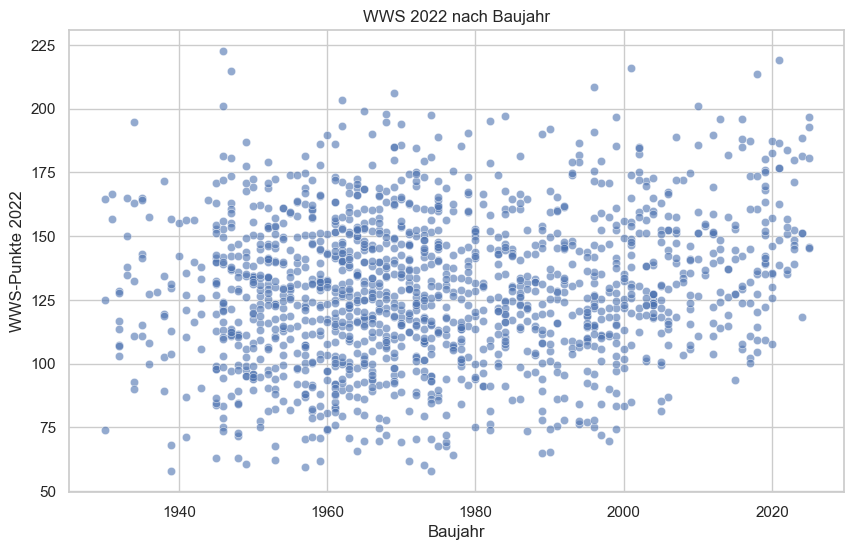

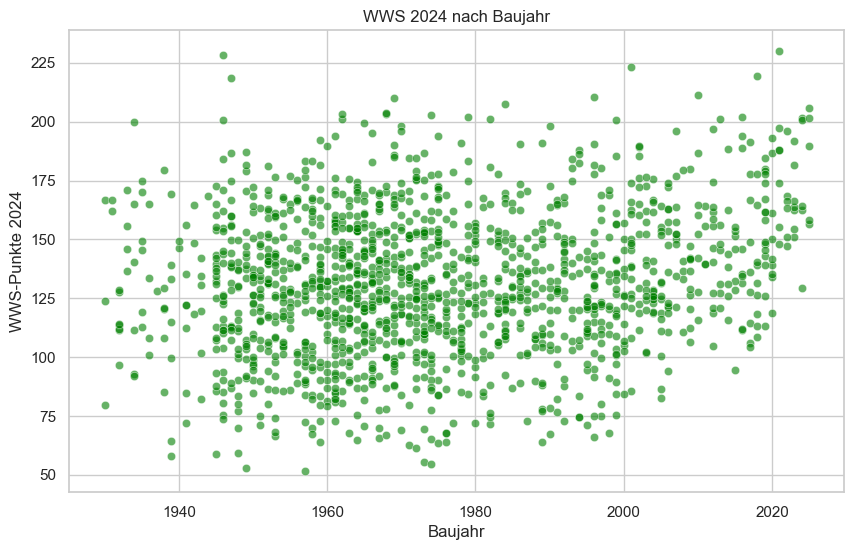

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_result,
    x="Bouwjaar",
    y="WWS_2022",
    alpha=0.6
)
plt.title("WWS 2022 nach Baujahr")
plt.xlabel("Baujahr")
plt.ylabel("WWS-Punkte 2022")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_result,
    x="Bouwjaar",
    y="WWS_2024",
    alpha=0.6,
    color="green"
)
plt.title("WWS 2024 nach Baujahr")
plt.xlabel("Baujahr")
plt.ylabel("WWS-Punkte 2024")
plt.show()


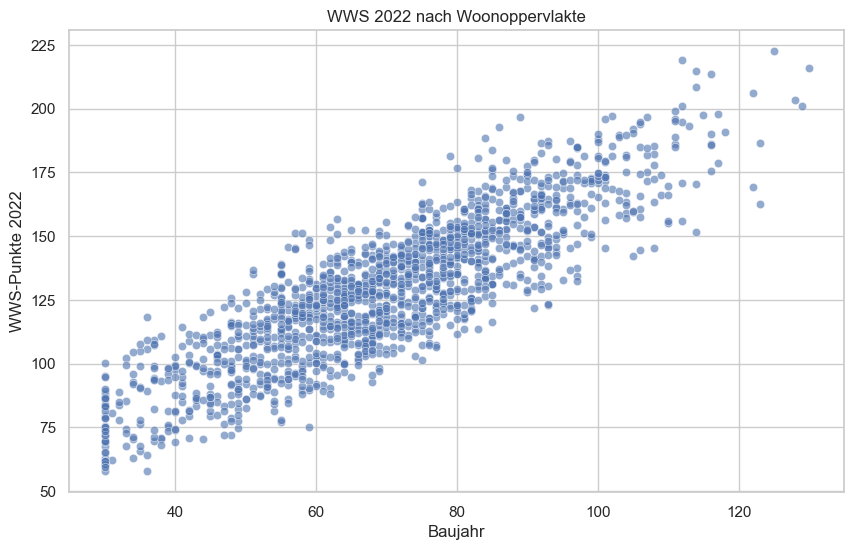

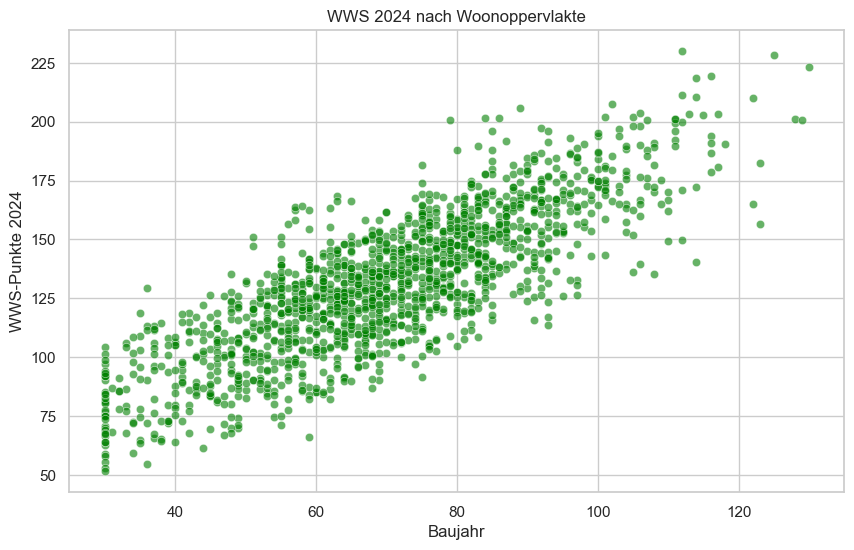

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_result,
    x="Woonoppervlakte",
    y="WWS_2022",
    alpha=0.6
)
plt.title("WWS 2022 nach Woonoppervlakte")
plt.xlabel("Baujahr")
plt.ylabel("WWS-Punkte 2022")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_result,
    x="Woonoppervlakte",
    y="WWS_2024",
    alpha=0.6,
    color="green"
)
plt.title("WWS 2024 nach Woonoppervlakte")
plt.xlabel("Baujahr")
plt.ylabel("WWS-Punkte 2024")
plt.show()


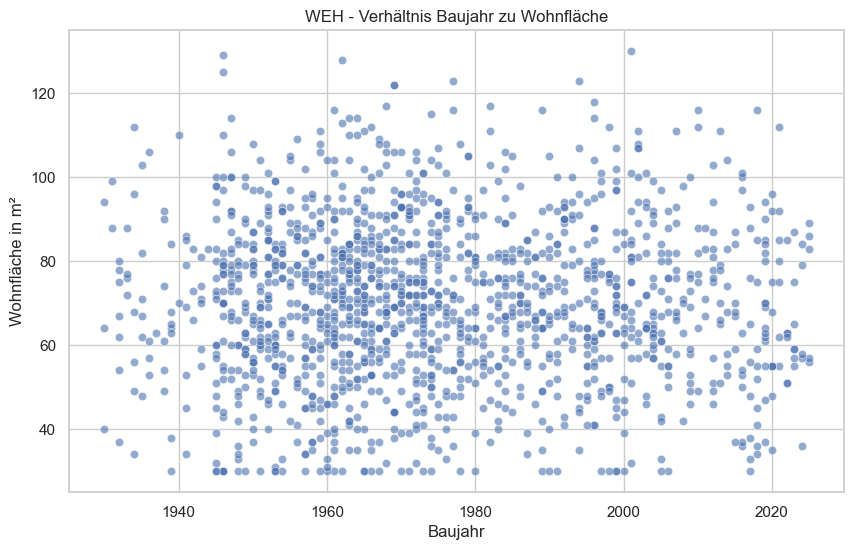

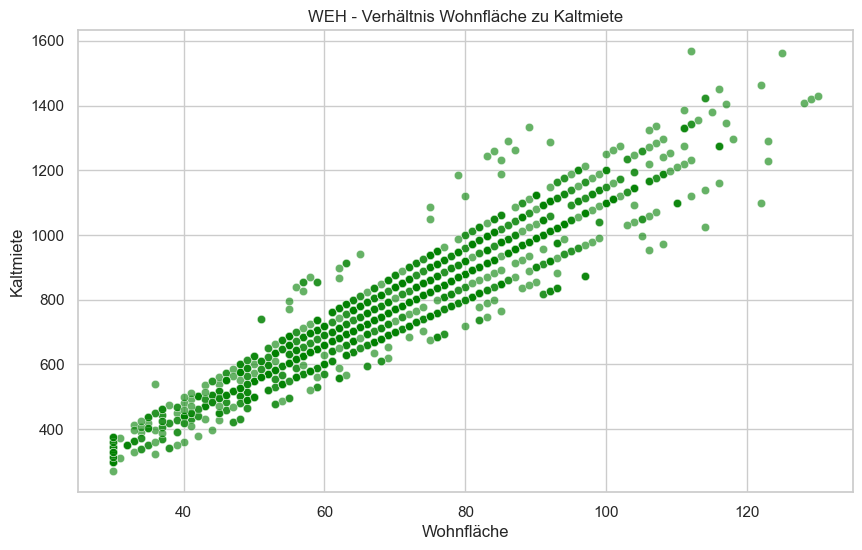

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_result,
    x="Bouwjaar",
    y="Woonoppervlakte",
    alpha=0.6
)
plt.title("WEH - Verhältnis Baujahr zu Wohnfläche")
plt.xlabel("Baujahr")
plt.ylabel("Wohnfläche in m²")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_result,
    x="Woonoppervlakte",
    y="Huur_kalt",
    alpha=0.6,
    color="green"
)
plt.title("WEH - Verhältnis Wohnfläche zu Kaltmiete")
plt.xlabel("Wohnfläche")
plt.ylabel("Kaltmiete")
plt.show()


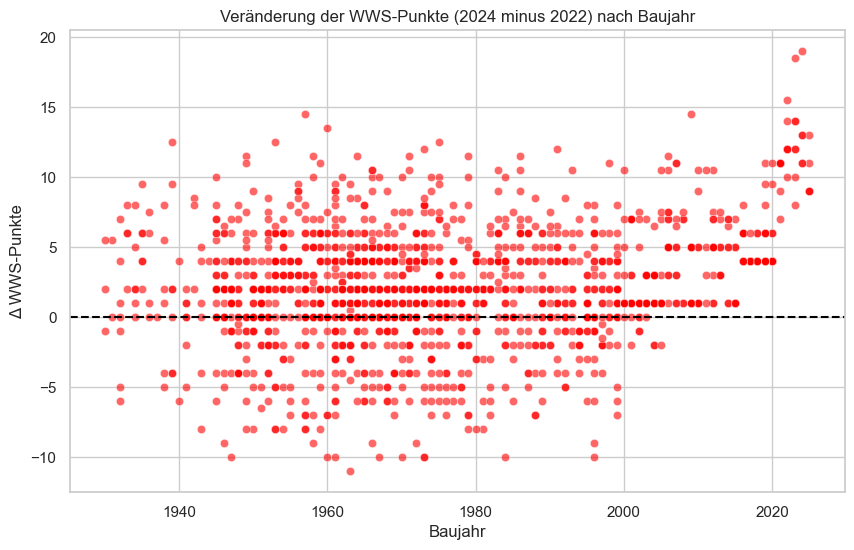

In [10]:
df_result["WWS_diff"] = df_result["WWS_2024"] - df_result["WWS_2022"]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_result,
    x="Bouwjaar",
    y="WWS_diff",
    alpha=0.6,
    color="red"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Veränderung der WWS-Punkte (2024 minus 2022) nach Baujahr")
plt.xlabel("Baujahr")
plt.ylabel("Δ WWS-Punkte")
plt.show()


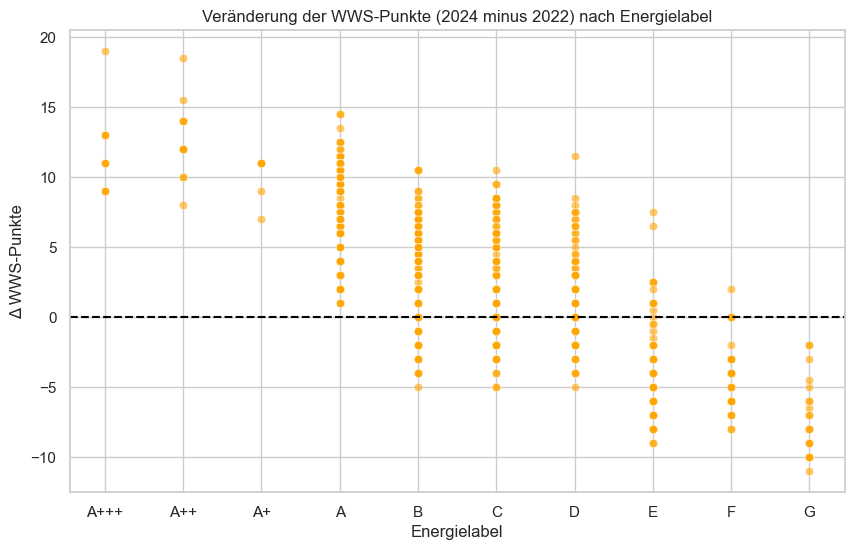

C:\Users\sk\AppData\Local\Temp\ipykernel_13028\2781256083.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




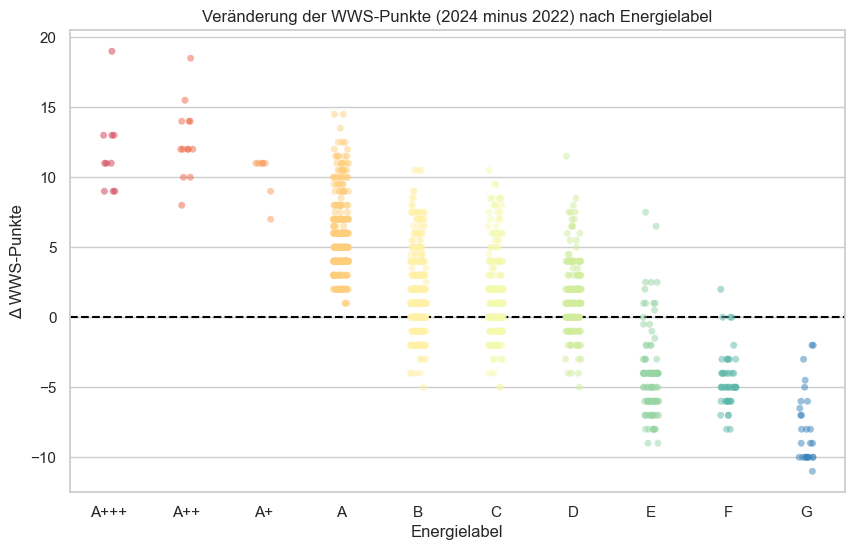

C:\Users\sk\AppData\Local\Temp\ipykernel_13028\2781256083.py:48: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




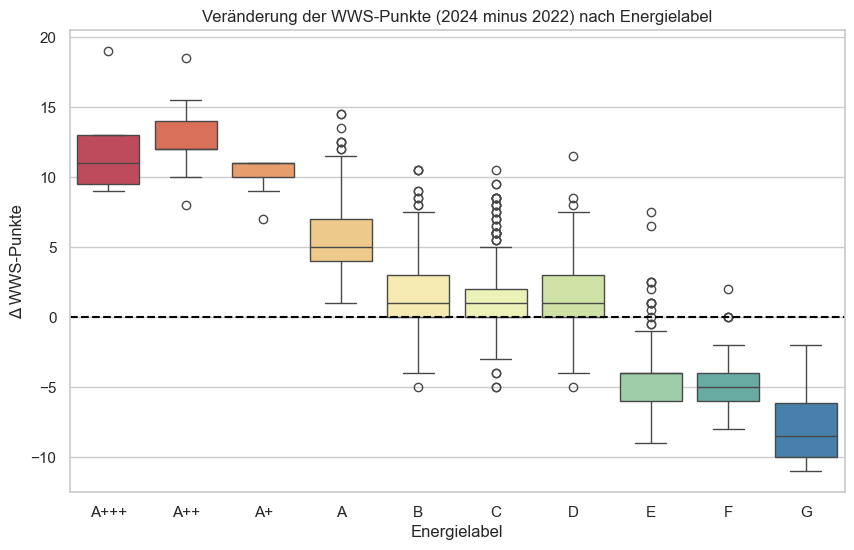

In [36]:
df_result["WWS_diff"] = df_result["WWS_2024"] - df_result["WWS_2022"]

labels_order = ["A+++", "A++", "A+", "A", "B", "C", "D", "E", "F", "G"]

df_result["Energielabel"] = pd.Categorical(
    df_result["Energielabel"],
    categories=labels_order,
    ordered=True
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_result,
    x="Energielabel",
    y="WWS_diff",
    alpha=0.6,
    color="orange"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Veränderung der WWS-Punkte (2024 minus 2022) nach Energielabel")
plt.xlabel("Energielabel")
plt.ylabel("Δ WWS-Punkte")
plt.show()


# Stripplot

plt.figure(figsize=(10, 6))
sns.stripplot(
    data=df_result,
    x="Energielabel",
    y="WWS_diff",
    order=labels_order,
    jitter=True,
    alpha=0.5,
    palette="Spectral"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Veränderung der WWS-Punkte (2024 minus 2022) nach Energielabel")
plt.xlabel("Energielabel")
plt.ylabel("Δ WWS-Punkte")
plt.show()


# Boxplot

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_result,
    x="Energielabel",
    y="WWS_diff",
    order=labels_order,
    palette="Spectral"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Veränderung der WWS-Punkte (2024 minus 2022) nach Energielabel")
plt.xlabel("Energielabel")
plt.ylabel("Δ WWS-Punkte")
plt.show()


C:\Users\sk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


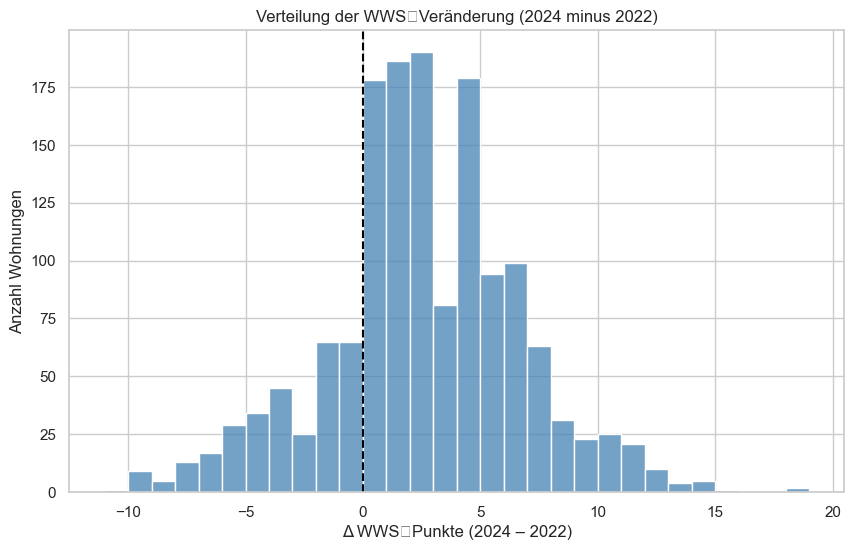

C:\Users\sk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


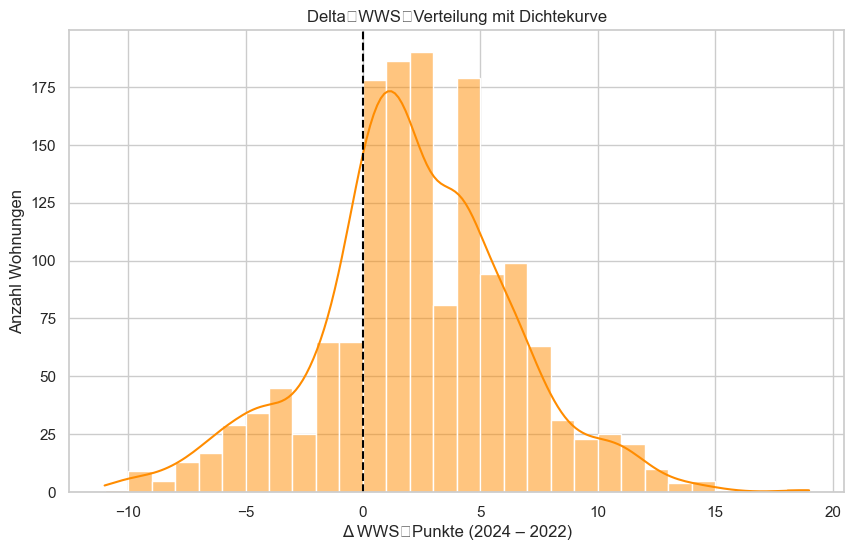

In [11]:
df_result["WWS_diff"] = df_result["WWS_2024"] - df_result["WWS_2022"]

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_result,
    x="WWS_diff",
    bins=30,
    kde=False,
    color="steelblue"
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Verteilung der WWS‑Veränderung (2024 minus 2022)")
plt.xlabel("Δ WWS‑Punkte (2024 – 2022)")
plt.ylabel("Anzahl Wohnungen")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_result,
    x="WWS_diff",
    bins=30,
    kde=True,
    color="darkorange"
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Delta‑WWS‑Verteilung mit Dichtekurve")
plt.xlabel("Δ WWS‑Punkte (2024 – 2022)")
plt.ylabel("Anzahl Wohnungen")
plt.show()


In [12]:
def huurklasse_2022(punten):
    if punten <= 143:
        return "sociale huursegment"
    else:
        return "vrije sector"


def huurklasse_2024(punten):
    if punten <= 143:
        return "sociale huursegment"
    elif punten <= 186:
        return "middenhuur"
    else:
        return "vrije sector"


df_result["Huurklasse_2022"] = df_result["WWS_2022"].apply(huurklasse_2022)
df_result["Huurklasse_2024"] = df_result["WWS_2024"].apply(huurklasse_2024)

df_result[["WWS_2022", "Huurklasse_2022", "WWS_2024", "Huurklasse_2024"]].head()



,WWS_2022,Huurklasse_2022,WWS_2024,Huurklasse_2024
0,148.46750,vrije sector,162.46750,middenhuur
1,103.56875,sociale huursegment,107.56875,sociale huursegment
2,146.50125,vrije sector,150.50125,middenhuur
3,100.81500,sociale huursegment,103.81500,sociale huursegment
4,109.04375,sociale huursegment,115.04375,sociale huursegment


In [13]:
import sys
!{sys.executable} -m pip install plotly



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\sk\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


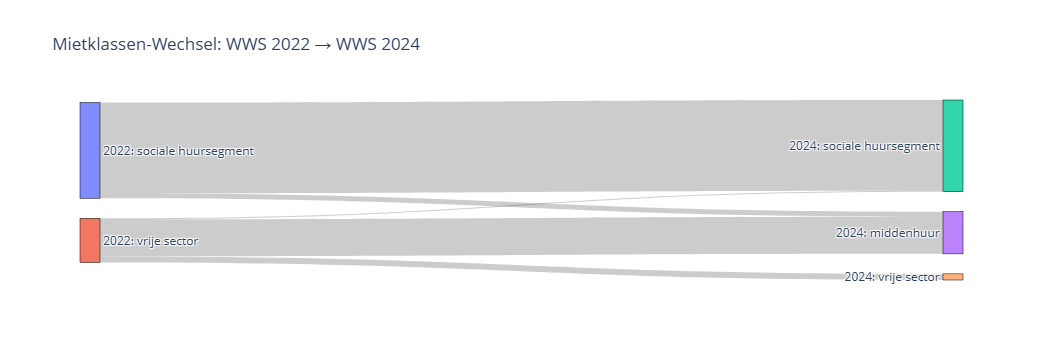

In [14]:
# =================================
# Sankey-Diagramm
# =================================


import plotly.graph_objects as go

# Knoten definieren
labels = [
    "2022: sociale huursegment",
    "2022: vrije sector",
    "2024: sociale huursegment",
    "2024: middenhuur",
    "2024: vrije sector"
]

node_map = {
    "2022_sociale": 0,
    "2022_vrije": 1,
    "2024_sociale": 2,
    "2024_midden": 3,
    "2024_vrije": 4
}

# Übergänge zählen
flows = {
    ("2022_sociale", "2024_sociale"): 0,
    ("2022_sociale", "2024_midden"): 0,
    ("2022_sociale", "2024_vrije"): 0,
    ("2022_vrije", "2024_sociale"): 0,
    ("2022_vrije", "2024_midden"): 0,
    ("2022_vrije", "2024_vrije"): 0
}

for _, row in df_result.iterrows():
    src = "2022_sociale" if row["Huurklasse_2022"] == "sociale huursegment" else "2022_vrije"
    
    if row["Huurklasse_2024"] == "sociale huursegment":
        tgt = "2024_sociale"
    elif row["Huurklasse_2024"] == "middenhuur":
        tgt = "2024_midden"
    else:
        tgt = "2024_vrije"
    
    flows[(src, tgt)] += 1

# Listen für Plotly
source = []
target = []
value = []

for (src, tgt), v in flows.items():
    source.append(node_map[src])
    target.append(node_map[tgt])
    value.append(v)

# Sankey erzeugen
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(title_text="Mietklassen-Wechsel: WWS 2022 → WWS 2024", font_size=12)
fig.show()


In [15]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"


In [16]:
import pandas as pd

transition_matrix = pd.crosstab(
    df_result["Huurklasse_2022"],
    df_result["Huurklasse_2024"],
    rownames=["2022"],
    colnames=["2024"],
    normalize=False
)

transition_matrix


2024,middenhuur,sociale huursegment,vrije sector
2022,,,
sociale huursegment,54,975,0
vrije sector,399,11,66


In [17]:
# Beispielwerte – bitte durch echte Werte ersetzen
huur_social = 650
huur_midden = 900
huur_vrij = 1400

# Einnahmen 2022
df_result["Huur_2022"] = df_result["Huurklasse_2022"].map({
    "sociale huursegment": huur_social,
    "vrije sector": huur_vrij
})

# Einnahmen 2024
df_result["Huur_2024"] = df_result["Huurklasse_2024"].map({
    "sociale huursegment": huur_social,
    "middenhuur": huur_midden,
    "vrije sector": huur_vrij
})

# Einnahmeverlust
df_result["Huur_diff"] = df_result["Huur_2024"] - df_result["Huur_2022"]

df_result["Huur_diff"].sum()


np.int64(-194250)

In [18]:
risk_downgrade = df_result[
    (df_result["Huurklasse_2022"] == "vrije sector") &
    (df_result["Huurklasse_2024"] == "middenhuur")
]


In [19]:
risk_borderline = df_result[
    (df_result["WWS_2024"] >= 170) & (df_result["WWS_2024"] < 187)
]


In [20]:
risk_loss = df_result[df_result["WWS_diff"] < 0]


In [21]:
import pandas as pd

# 1. Excel-Datei einlesen
excel_path = "fictief_woningportfolio_nl_final.xlsx"
df_excel = pd.read_excel(excel_path)

# 2. Sicherstellen, dass beide DataFrames dieselbe Schlüsselspalte haben
# Beispiel: "Woning_ID" – bitte ggf. anpassen
key = "WEH_ID"

# 3. Merge der WWS-Ergebnisse in die Excel-Liste
df_merged = df_excel.merge(
    df_result[[key, "WWS_2022", "WWS_2024"]],
    on=key,
    how="left"
)

# 4. Neue Excel-Datei speichern (empfohlen)
output_path = "fictief_woningportfolio_nl_final_mit_WWS.xlsx"
df_merged.to_excel(output_path, index=False)

print("WWS-Punkte erfolgreich in Excel übernommen!")


WWS-Punkte erfolgreich in Excel übernommen!


In [22]:
df_result.head(5)

,WEH_ID,Gemeente,Provincie,Straat,Huisnummer,Postcode,Woonoppervlakte,Kamers,Verdieping,Verdiepingen_totaal,...,Brutto-Rendite / monat,WOZ_waarde_alt,WWS_2022,WWS_2024,WWS_diff,Huurklasse_2022,Huurklasse_2024,Huur_2022,Huur_2024,Huur_diff
0,W1485,Assen,Drenthe,Bremstraat,30.0,9401 NP,59.0,2.0,0.0,2.0,...,0.005,148700.0,148.46750,162.46750,14.0,vrije sector,middenhuur,1400,900,-500
1,W1057,Assen,Drenthe,Kanaalstraat,12.0,9406 CD,46.0,2.0,3.0,6.0,...,0.005,127600.0,103.56875,107.56875,4.0,sociale huursegment,sociale huursegment,650,650,0
2,W0731,Assen,Drenthe,Eikenlaan,138.0,9401 AB,75.0,3.0,4.0,6.0,...,0.005,188100.0,146.50125,150.50125,4.0,vrije sector,middenhuur,1400,900,-500
3,W0500,Assen,Drenthe,Watermolenweg,36.0,9401 GH,50.0,2.0,5.0,6.0,...,0.005,138300.0,100.81500,103.81500,3.0,sociale huursegment,sociale huursegment,650,650,0
4,W0495,Assen,Drenthe,Meidoornstraat,144.0,9401 EF,42.0,1.0,1.0,3.0,...,0.005,101500.0,109.04375,115.04375,6.0,sociale huursegment,sociale huursegment,650,650,0


In [23]:
import numpy as np
import pandas as pd

# Stützpunkte für WWS 2022
wws_points = np.array([40, 60, 80, 100, 120, 141, 142, 180, 250])
wws_rent = np.array([215.92, 316.91, 418.22, 522.57, 632.54, 
                     764.18, 772.01, 1082.75, 1638.01])

# Funktion zur Interpolation
def maxhuur_2022(punten):
    # Punkte unterhalb oder oberhalb der Tabelle werden am Rand fixiert
    punten = np.clip(punten, wws_points.min(), wws_points.max())
    return float(np.interp(punten, wws_points, wws_rent))

# Neue Spalte: zulässige Miete nach WWS 2022
df_result["Maxhuur_2022"] = df_result["WWS_2022"].apply(maxhuur_2022)

# Segment nach WWS 2022
df_result["Segment_2022"] = np.where(df_result["WWS_2022"] <= 142, 
                                     "sociaal", "vrij")

# Prüfung: Miete zu hoch?
df_result["Miete_zu_hoch_2022"] = df_result["Huur_kalt"] > df_result["Maxhuur_2022"]

# Übermiete in Euro
df_result["Uebermiete_2022"] = df_result["Huur_kalt"] - df_result["Maxhuur_2022"]
df_result.loc[df_result["Uebermiete_2022"] < 0, "Uebermiete_2022"] = 0


In [24]:
sozial = df_result[df_result["Segment_2022"] == "sociaal"]

print("Anzahl sozialer Wohnungen:", len(sozial))
print("Davon über der zulässigen Miete:", sozial["Miete_zu_hoch_2022"].sum())
print("Durchschnittliche Übermiete (nur betroffene):",
      round(sozial.loc[sozial["Miete_zu_hoch_2022"], "Uebermiete_2022"].mean(), 2))
print("Gesamte Übermiete pro Monat:",
      round(sozial["Uebermiete_2022"].sum(), 2))


Anzahl sozialer Wohnungen: 1008
Davon über der zulässigen Miete: 799
Durchschnittliche Übermiete (nur betroffene): 90.79
Gesamte Übermiete pro Monat: 72539.12


In [25]:
import pandas as pd

# Pfad zur bestehenden Excel-Datei
excel_path = r"C:\Users\sk\fictief_woningportfolio_nl_final_mit_WWS.xlsx"

# Excel einlesen
df_excel = pd.read_excel(excel_path, sheet_name="Sheet1")

# Sicherstellen, dass beide DataFrames dieselbe ID-Spalte haben
# Falls deine ID anders heißt, bitte hier anpassen
key = "WEH_ID"

# Nur die neue Huur_markt-Spalte aus df_result übernehmen
df_update = df_result[[key, "Huur_markt"]]

# Merge: überschreibt die alte Huur_markt-Spalte
df_merged = df_excel.drop(columns=["Huur_markt"], errors="ignore") \
                    .merge(df_update, on=key, how="left")

# Zurückschreiben in dieselbe Datei
df_merged.to_excel(excel_path, sheet_name="Sheet1", index=False)

print("Neue Huur_markt-Werte erfolgreich in die Excel-Datei geschrieben.")


Neue Huur_markt-Werte erfolgreich in die Excel-Datei geschrieben.


In [26]:
# Erhöhung des Bestandes in 2023 auf Basis der 'Huur_kalt_2022' 
# > Erhöhung aller Wohnungen mit einem Energielabel C und besser um 2,3% (Ergebnis: 'Huur_kalt_2023)

import pandas as pd

excel_path = r"C:\Users\sk\fictief_woningportfolio_nl_final_mit_WWS.xlsx"

# Datei laden
df = pd.read_excel(excel_path, sheet_name="Sheet1")

# Spalten umbenennen (nur diese beiden!)
df = df.rename(columns={
    "Huur_kalt": "Huur_kalt_2022",
    "Huur/m²": "Huur/m²_2022"
})

# Kontrolle
print("Spalten nach Umbenennung:")
print(df.columns)


# Energielabels, die KEINE Erhöhung bekommen
schlechte_labels = ["D", "E", "F", "G"]

# Neue Spalte für 2023-Miete (initial identisch mit 2022)
df["Huur_kalt_2023"] = df["Huur_kalt_2022"]

# Maske für gute Labels
maske = ~df["Energielabel"].astype(str).str.upper().isin(schlechte_labels)

# Erhöhung um 2,3 %
df.loc[maske, "Huur_kalt_2023"] = df.loc[maske, "Huur_kalt_2022"] * 1.023

# Runden
df["Huur_kalt_2023"] = df["Huur_kalt_2023"].round(2)

# Kontrolle
print("Anzahl erhöhter Wohnungen:", maske.sum())


Spalten nach Umbenennung:
Index(['WEH_ID', 'Gemeente', 'Provincie', 'Straat', 'Huisnummer', 'Postcode',
       'Woonoppervlakte', 'Kamers', 'Verdieping', 'Verdiepingen_totaal',
       'Balkon', 'Tuin', 'Lift', 'Keuken', 'Badkamer', 'Ligging', 'Bouwjaar',
       'Energielabel', 'Verwarming', 'Isolatie', 'Warmtepomp',
       'Zonnepanelen_Wp', 'Huur_kalt_2022', 'Huur/m²_2022', 'Leegstand',
       'm2_vertrekken', 'm2_overig', 'Buitenruimte', 'Buitenruimte_m2',
       'WOZ_waarde', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33',
       'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'WOZ/m²',
       'Brutto-Rendite / monat', 'WOZ_waarde_alt', 'WWS_2022', 'WWS_2024',
       'Huur_markt'],
      dtype='object')
Anzahl erhöhter Wohnungen: 1250


In [27]:
df.to_excel(excel_path, sheet_name="Sheet1", index=False)

print("Excel-Datei erfolgreich aktualisiert – alle neuen Variablen wurden hinzugefügt.")


Excel-Datei erfolgreich aktualisiert – alle neuen Variablen wurden hinzugefügt.


In [28]:
# Abgleich der 'Huur_kalt 2023' mit den Vorgaben des WWS_2024

import pandas as pd
import numpy as np

excel_path = r"C:\Users\sk\fictief_woningportfolio_nl_final_mit_WWS.xlsx"

# Datei laden
df = pd.read_excel(excel_path, sheet_name="Sheet1")

# ---------------------------------------------------------
# 1. WWS 2024 – Stützpunkte definieren
# ---------------------------------------------------------

wws_points_2024 = np.array([40, 60, 80, 100, 120, 141, 143, 144, 180, 186])
wws_rent_2024 = np.array([
    239.36,   # 40
    351.32,   # 60
    463.64,   # 80
    579.31,   # 100
    701.23,   # 120
    858.35,   # 141
    879.66,   # 143 (Liberalisierungsgrenze)
    879.67,   # 144 (Beginn middenhuur)
    1111.76,  # 180
    1157.95   # 186 (Obergrenze middenhuur)
])

# ---------------------------------------------------------
# 2. Interpolationsfunktion für Maxhuur 2024
# ---------------------------------------------------------

def maxhuur_2024(punten):
    # Punkte außerhalb des Bereichs werden auf min/max begrenzt
    punten = np.clip(punten, wws_points_2024.min(), wws_points_2024.max())
    return float(np.interp(punten, wws_points_2024, wws_rent_2024))

# ---------------------------------------------------------
# 3. Neue Spalte: Maximaal toegestane huur volgens WWS 2024
# ---------------------------------------------------------

df["Maxhuur_2024"] = df["WWS_2024"].apply(maxhuur_2024).round(2)

# ---------------------------------------------------------
# 4. Vergleich: Ist die Miete 2023 zu hoch?
# ---------------------------------------------------------

df["Huur_te_hoog_2024"] = df["Huur_kalt_2023"] > df["Maxhuur_2024"]

# ---------------------------------------------------------
# 5. Overhuur 2024 (nur positive Differenzen)
# ---------------------------------------------------------

df["Overhuur_2024"] = df["Huur_kalt_2023"] - df["Maxhuur_2024"]
df.loc[df["Overhuur_2024"] < 0, "Overhuur_2024"] = 0
df["Overhuur_2024"] = df["Overhuur_2024"].round(2)

# ---------------------------------------------------------
# 6. Segment 2024 bestimmen
# ---------------------------------------------------------

def segment_2024(punten):
    if punten <= 142:
        return "sociaal"
    elif 143 <= punten <= 186:
        return "middenhuur"
    else:
        return "vrij"

df["Segment_2024"] = df["WWS_2024"].apply(segment_2024)

# ---------------------------------------------------------
# 7. Datei speichern
# ---------------------------------------------------------

df.to_excel(excel_path, sheet_name="Sheet1", index=False)

print("WWS 2024 erfolgreich berechnet und in Excel gespeichert.")


WWS 2024 erfolgreich berechnet und in Excel gespeichert.


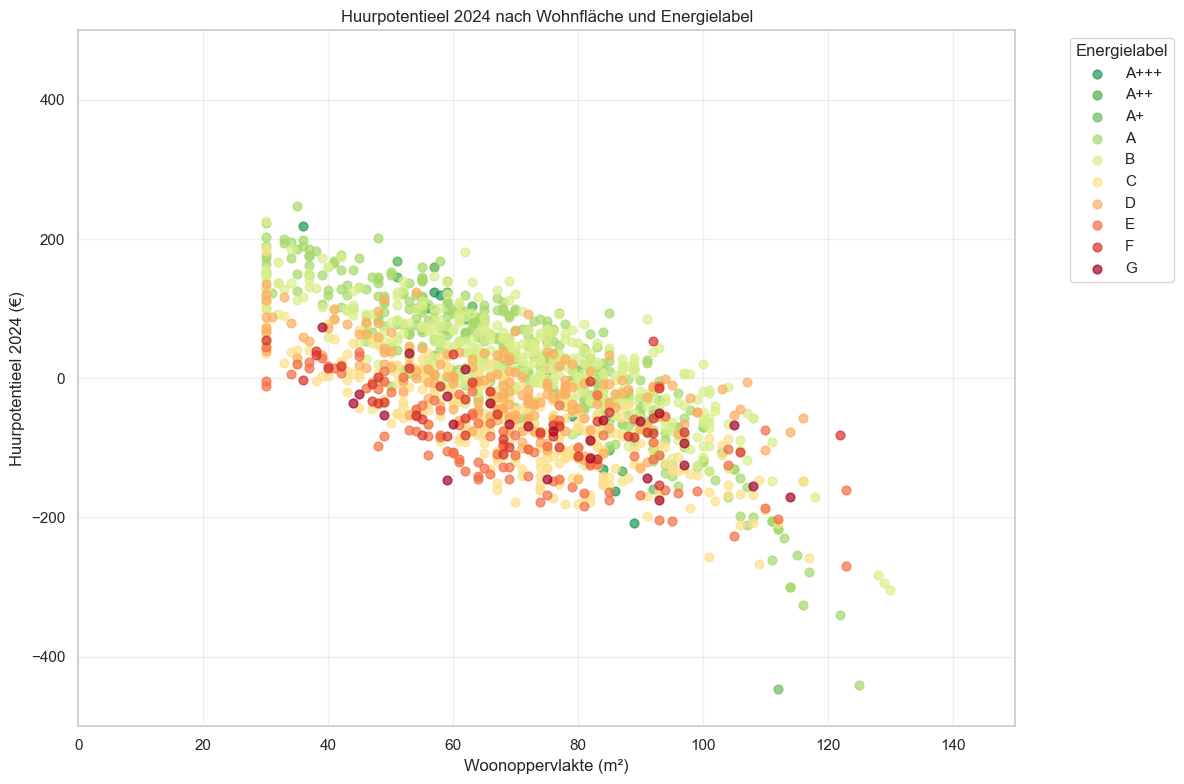

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Datei laden
excel_path = r"C:\Users\sk\fictief_woningportfolio_nl_final_mit_WWS_ II.xlsx"
df = pd.read_excel(excel_path, sheet_name="Sheet1")

# Energielabel säubern
df["Energielabel_clean"] = (
    df["Energielabel"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Farbzuordnung
labels_order = ["A+++", "A++", "A+", "A", "B", "C", "D", "E", "F", "G"]
colors = {
    "A+++": "#1a9850",
    "A++":  "#4daf4a",
    "A+":   "#66bd63",
    "A":    "#a6d96a",
    "B":    "#d9ef8b",
    "C":    "#fee08b",
    "D":    "#fdae61",
    "E":    "#f46d43",
    "F":    "#d73027",
    "G":    "#a50026"
}

# Plot vorbereiten
plt.figure(figsize=(12, 8))

for label in labels_order:
    subset = df[df["Energielabel_clean"] == label]
    if subset.empty:
        continue

    plt.scatter(
        subset["Woonoppervlakte"],
        subset["Huurpotentieel_2024"],
        s=40,
        alpha=0.7,
        c=colors[label],
        label=label
    )

# Achsenlimits
plt.xlim(0, 150)
plt.ylim(-500, 500)

# Achsenbeschriftung
plt.xlabel("Woonoppervlakte (m²)")
plt.ylabel("Huurpotentieel 2024 (€)")

# Titel
plt.title("Huurpotentieel 2024 nach Wohnfläche und Energielabel")

# Legende
plt.legend(title="Energielabel", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

